In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score


# ============================================================
# 0. Load multi-stock orderbook data
# ============================================================

data_path = Path("../Project_Train_Datasets")

file_map = {
    "AMZN": data_path / "AMZN_5levels_train.csv",
    "GOOG": data_path / "GOOG_5levels_train.csv",
    "INTC": data_path / "INTC_5levels_train.csv",
    "MSFT": data_path / "MSFT_5levels_train.csv",
}


def load_orderbook_data(file_map):
    """
    Load all stock orderbook CSVs and combine into one dataframe.

    Output:
        df with a new column: stock
    """

    dfs = []

    for stock, file_path in file_map.items():
        temp = pd.read_csv(file_path)
        temp["stock"] = stock
        dfs.append(temp)

    df = pd.concat(dfs, ignore_index=True)

    print("Loaded dataframe shape:", df.shape)
    print(df["stock"].value_counts())

    return df


# ============================================================
# 1. Build time columns
# ============================================================

def add_time_columns(df):
    """
    Create timestamp/minute columns.

    Your Time column looks like intraday time, e.g. HH:MM:SS.sss.
    We convert it to datetime and then create minute buckets.

    Important:
        minute is only used within each stock.
    """

    df = df.copy()

    df["ts"] = pd.to_datetime(df["Time"], format="%H:%M:%S.%f", errors="coerce")

    # Fallback if some rows do not match the exact format
    if df["ts"].isna().any():
        df["ts"] = pd.to_datetime(df["Time"], errors="coerce")

    df = df.dropna(subset=["ts"]).copy()

    df["minute"] = df["ts"].dt.floor("min")

    # Optional: position inside each stock-minute
    df["event_idx_in_min"] = df.groupby(["stock", "minute"]).cumcount()
    df["n_events_in_min"] = df.groupby(["stock", "minute"])["Time"].transform("size")
    df["event_frac_in_min"] = df["event_idx_in_min"] / np.maximum(df["n_events_in_min"] - 1, 1)

    return df


# ============================================================
# 2. Build orderbook regime features
# ============================================================

def build_regime_features(df):
    """
    Build K-Means features from 5-level orderbook data.

    Regime features describe:
        liquidity
        spread
        imbalance
        microprice pressure
        short-term instability
    """

    df = df.copy()

    # Sort first so diff() is meaningful
    df = df.sort_values(["stock", "ts"]).reset_index(drop=True)

    # Best bid / ask
    df["bid1"] = df["BidPrice_1"]
    df["ask1"] = df["AskPrice_1"]
    df["bsz1"] = df["BidSize_1"]
    df["asz1"] = df["AskSize_1"]

    # Midprice and spread
    df["mid"] = (df["bid1"] + df["ask1"]) / 2
    df["spread"] = df["ask1"] - df["bid1"]
    df["rel_spread"] = df["spread"] / df["mid"]

    # Top-level imbalance
    df["imbalance_1"] = (df["bsz1"] - df["asz1"]) / (df["bsz1"] + df["asz1"])

    # 5-level depth
    bid_size_cols = [f"BidSize_{i}" for i in range(1, 6)]
    ask_size_cols = [f"AskSize_{i}" for i in range(1, 6)]

    df["total_bid_size_5"] = df[bid_size_cols].sum(axis=1)
    df["total_ask_size_5"] = df[ask_size_cols].sum(axis=1)

    df["imbalance_5"] = (
        df["total_bid_size_5"] - df["total_ask_size_5"]
    ) / (
        df["total_bid_size_5"] + df["total_ask_size_5"]
    )

    # Microprice
    df["microprice"] = (
        df["ask1"] * df["bsz1"] + df["bid1"] * df["asz1"]
    ) / (
        df["bsz1"] + df["asz1"]
    )

    df["micro_minus_mid"] = df["microprice"] - df["mid"]

    # Changes should be computed within each stock only
    df["mid_chg1"] = df.groupby("stock")["mid"].diff()
    df["spread_chg1"] = df.groupby("stock")["spread"].diff()
    df["imbalance_1_chg1"] = df.groupby("stock")["imbalance_1"].diff()
    df["imbalance_5_chg1"] = df.groupby("stock")["imbalance_5"].diff()

    # Absolute movement proxies
    df["abs_mid_chg1"] = df["mid_chg1"].abs()
    df["abs_spread_chg1"] = df["spread_chg1"].abs()
    df["abs_imbalance_1_chg1"] = df["imbalance_1_chg1"].abs()
    df["abs_imbalance_5_chg1"] = df["imbalance_5_chg1"].abs()

    regime_features = [
        "rel_spread",
        "imbalance_1",
        "imbalance_5",
        "micro_minus_mid",
        "total_bid_size_5",
        "total_ask_size_5",
        "abs_mid_chg1",
        "abs_spread_chg1",
        "abs_imbalance_1_chg1",
        "abs_imbalance_5_chg1",
    ]

    df[regime_features] = (
        df[regime_features]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    return df, regime_features


# ============================================================
# 3. Train / test split by stock + minute
# ============================================================

def train_test_split_by_stock_minute(df, train_frac=0.7):
    """
    Split each stock chronologically by minute.

    Why:
        AMZN, GOOG, INTC, MSFT can share the same minute values.
        Splitting within each stock avoids mixing each stock's timeline incorrectly.
    """

    df = df.copy()

    train_parts = []
    test_parts = []

    for stock, g in df.groupby("stock"):
        g = g.sort_values("ts").copy()

        unique_minutes = np.array(sorted(g["minute"].unique()))
        split_idx = int(len(unique_minutes) * train_frac)

        train_minutes = unique_minutes[:split_idx]
        test_minutes = unique_minutes[split_idx:]

        train_parts.append(g[g["minute"].isin(train_minutes)])
        test_parts.append(g[g["minute"].isin(test_minutes)])

    train_df = pd.concat(train_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)

    print("Train shape:", train_df.shape)
    print("Test shape:", test_df.shape)

    return train_df, test_df


# ============================================================
# 4. Choose K using silhouette score
# ============================================================

def choose_best_k(
    train_df,
    regime_features,
    k_list=[3, 4, 5, 6],
    random_state=42,
    sample_size=50000
):
    """
    Choose K using silhouette score.

    Note:
        silhouette_score can be slow on very large data.
        So we use a random sample from train data.
    """

    X_train = train_df[regime_features].values

    if len(X_train) > sample_size:
        sample_idx = np.random.default_rng(random_state).choice(
            len(X_train),
            size=sample_size,
            replace=False
        )
        X_eval = X_train[sample_idx]
    else:
        X_eval = X_train

    results = []

    for k in k_list:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("kmeans", KMeans(
                n_clusters=k,
                random_state=random_state,
                n_init=20
            ))
        ])

        labels = pipe.fit_predict(X_eval)

        score = silhouette_score(
            pipe.named_steps["scaler"].transform(X_eval),
            labels
        )

        results.append({
            "k": k,
            "silhouette_score": score
        })

    result_df = pd.DataFrame(results).sort_values(
        "silhouette_score",
        ascending=False
    )

    best_k = int(result_df.iloc[0]["k"])

    return best_k, result_df


# ============================================================
# 5. Fit K-Means regime model
# ============================================================

def fit_kmeans_regime_model(train_df, regime_features, n_clusters=4, random_state=42):
    """
    Fit scaler + KMeans only on training data.
    Do not fit on full data, otherwise there is look-ahead leakage.
    """

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("kmeans", KMeans(
            n_clusters=n_clusters,
            random_state=random_state,
            n_init=20
        ))
    ])

    model.fit(train_df[regime_features])

    return model


# ============================================================
# 6. Assign regimes
# ============================================================

def assign_regimes(df, model, regime_features):
    """
    Assign regime label to each row.
    """

    df = df.copy()
    df["regime"] = model.predict(df[regime_features])

    return df


# ============================================================
# 7. Summarize regimes
# ============================================================

def summarize_regimes(df, regime_features):
    """
    Show average feature values in each regime.
    This helps interpret each K-Means cluster economically.
    """

    summary = df.groupby("regime")[regime_features].mean()

    counts = df["regime"].value_counts().sort_index()
    summary["count"] = counts
    summary["pct"] = counts / len(df)

    return summary.sort_index()


def summarize_regimes_by_stock(df):
    """
    Show how regimes are distributed for each stock.
    """

    return pd.crosstab(
        df["stock"],
        df["regime"],
        normalize="index"
    )


In [2]:
# ============================================================
# 8. Full pipeline
# ============================================================

df = load_orderbook_data(file_map)

df = add_time_columns(df)

df, regime_features = build_regime_features(df)

train_df, test_df = train_test_split_by_stock_minute(
    df,
    train_frac=0.7
)

best_k, k_result = choose_best_k(
    train_df,
    regime_features,
    k_list=[3, 4, 5, 6],
    random_state=42,
    sample_size=50000
)

print("\nK selection result:")
print(k_result)
print("\nBest K:", best_k)

regime_model = fit_kmeans_regime_model(
    train_df,
    regime_features,
    n_clusters=best_k,
    random_state=42
)

train_df = assign_regimes(train_df, regime_model, regime_features)
test_df = assign_regimes(test_df, regime_model, regime_features)

regime_summary_train = summarize_regimes(train_df, regime_features)
regime_summary_test = summarize_regimes(test_df, regime_features)

print("\nTrain regime summary:")
print(regime_summary_train)

print("\nTest regime summary:")
print(regime_summary_test)

print("\nTrain regime distribution by stock:")
print(summarize_regimes_by_stock(train_df))

print("\nTest regime distribution by stock:")
print(summarize_regimes_by_stock(test_df))

Loaded dataframe shape: (1149529, 34)
stock
MSFT    443425
INTC    430718
AMZN    175338
GOOG    100048
Name: count, dtype: int64
Train shape: (883579, 60)
Test shape: (265950, 60)

K selection result:
   k  silhouette_score
2  5          0.404888
1  4          0.403452
3  6          0.402997
0  3          0.381389

Best K: 5

Train regime summary:
        rel_spread  imbalance_1  imbalance_5  micro_minus_mid  \
regime                                                          
0         0.000601    -0.378397    -0.169311        -0.031531   
1         0.000415    -0.008783     0.018849        -0.000054   
2         0.000657     0.050852     0.066247         0.004382   
3         0.000578     0.493758     0.275555         0.031857   
4         0.000840    -0.120572    -0.033068        -0.042182   

        total_bid_size_5  total_ask_size_5  abs_mid_chg1  abs_spread_chg1  \
regime                                                                      
0            6074.060870       8917.679

In [3]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# ============================================================
# 11. Visualize K-Means regimes using PCA
# ============================================================

def plot_kmeans_pca(
    df,
    regime_features,
    model,
    sample_size=30000,
    title="K-Means Regime Visualization with PCA",
    random_state=42
):
    """
    Visualize high-dimensional K-Means regimes in 2D using PCA.

    Steps:
        1. Take regime features
        2. Apply the same scaler used in K-Means
        3. Reduce to 2D using PCA
        4. Plot points colored by regime

    中文：
        K-Means 本身在多维空间聚类。
        PCA 只是把多维特征压缩成二维，方便可视化。
    """

    plot_df = df.copy()

    if len(plot_df) > sample_size:
        plot_df = plot_df.sample(sample_size, random_state=random_state)

    X = plot_df[regime_features]

    scaler = model.named_steps["scaler"]

    X_scaled = scaler.transform(X)

    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X_scaled)

    plot_df["PC1"] = X_pca[:, 0]
    plot_df["PC2"] = X_pca[:, 1]

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(
        plot_df["PC1"],
        plot_df["PC2"],
        c=plot_df["regime"],
        s=5,
        alpha=0.5
    )

    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)")
    plt.title(title)
    plt.colorbar(scatter, label="Regime")
    plt.grid(True, alpha=0.3)
    plt.show()

    print("Explained variance by PC1 and PC2:")
    print(pca.explained_variance_ratio_)
    print("Total explained variance:")
    print(pca.explained_variance_ratio_.sum())

    return plot_df, pca

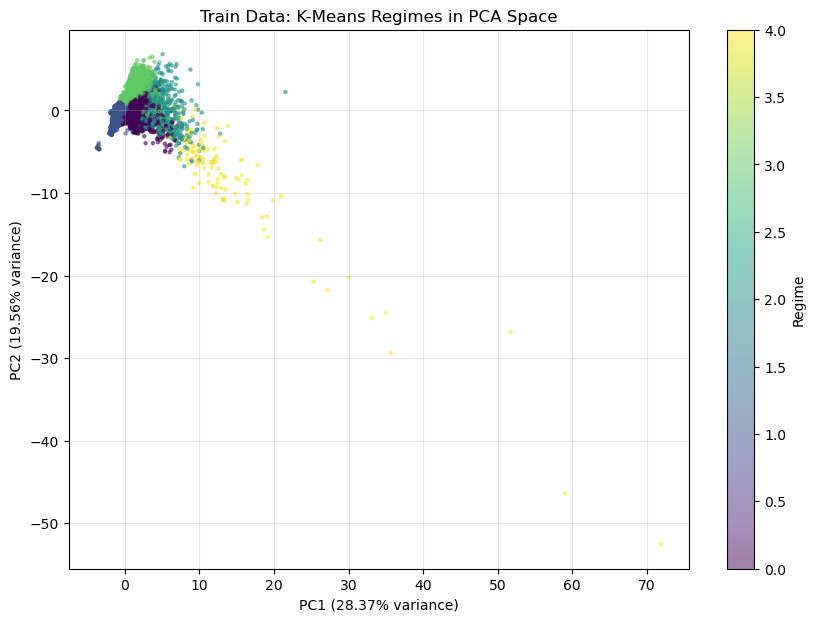

Explained variance by PC1 and PC2:
[0.28374631 0.19556002]
Total explained variance:
0.4793063271328026


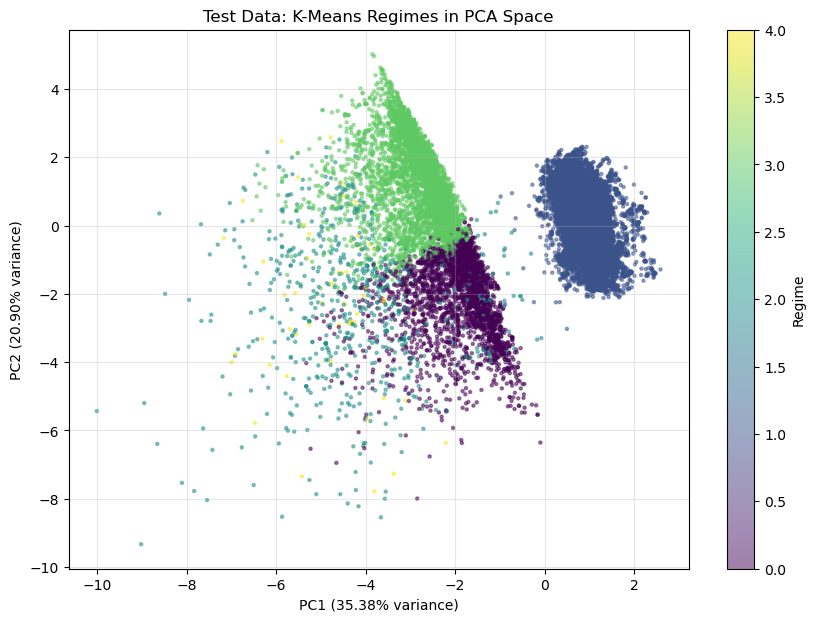

Explained variance by PC1 and PC2:
[0.35382258 0.20900403]
Total explained variance:
0.5628266065350616


In [4]:
plot_train_df, pca_train = plot_kmeans_pca(
    train_df,
    regime_features,
    regime_model,
    sample_size=30000,
    title="Train Data: K-Means Regimes in PCA Space"
)

plot_test_df, pca_test = plot_kmeans_pca(
    test_df,
    regime_features,
    regime_model,
    sample_size=30000,
    title="Test Data: K-Means Regimes in PCA Space"
)

In [5]:
train_df["sample"] = "train"
test_df["sample"] = "test"

df_with_regime = pd.concat([train_df, test_df], ignore_index=True)

# Save to current folder
regime_output_path = Path("orderbook_with_kmeans_regime.csv")

df_with_regime.to_csv(regime_output_path, index=False)

print(f"Saved regime file to: {regime_output_path.resolve()}")
print("Saved shape:", df_with_regime.shape)
print(df_with_regime[["stock", "Time", "OrderID", "regime", "sample"]].head())

Saved regime file to: /Users/chenyu/Desktop/ORIE5259 Market Microstructure/ORIE-5259-Algo-Trading/Milestone 2/orderbook_with_kmeans_regime.csv
Saved shape: (1149529, 62)
  stock          Time   OrderID  regime sample
0  AMZN  09:30:00.017         0       0  train
1  AMZN  09:30:00.189   4631805       0  train
2  AMZN  09:30:00.189   8788376       0  train
3  AMZN  09:30:00.189   3579342       0  train
4  AMZN  09:30:00.189  11561639       0  train
